# **✨ Project: Wrangling and Analyze Data**

### **Table Of Contents**

1. [🧰 Data Gathering](#gather)
2. [🔎 Assessing Data](#assess) 
    * 2.1 [Visual Assessment](#visual)
    * 2.2 [Programmatic Assessment](#programmatic)
3. [💎 Cleaning](#cleaning)
4. [💾 Storing Data](#storing)
5. [📊 Analyzing & Visualizing](#analyzing)

## **🧰Data Gathering**

<a id="gather"></a>

In the cell below, gather **all** three pieces of data for this project and load them in the notebook. **Note:** the methods required to gather each data are different.
1. Directly download the WeRateDogs Twitter archive data (twitter_archive_enhanced.csv)

In [1]:
import re
import json
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from os import path
from requests import get

%matplotlib inline

sns.set(rc={'figure.figsize':(11.7,8.27)})

# Twitter Archive File
twitter_archive = pd.read_csv("resources/twitter-archive-enhanced.csv")
twitter_archive.sort_values("timestamp")
twitter_archive.head(5)


,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,892420643555336193,NaN,NaN,2017-08-01 16:23:56 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,None,None,None,None
1,892177421306343426,NaN,NaN,2017-08-01 00:17:27 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421...,13,10,Tilly,None,None,None,None
2,891815181378084864,NaN,NaN,2017-07-31 00:18:03 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181...,12,10,Archie,None,None,None,None
3,891689557279858688,NaN,NaN,2017-07-30 15:58:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557...,13,10,Darla,None,None,None,None
4,891327558926688256,NaN,NaN,2017-07-29 16:00:24 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891327558...,12,10,Franklin,None,None,None,None


In [2]:
twitter_archive.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2356 entries, 0 to 2355
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   tweet_id                    2356 non-null   int64  
 1   in_reply_to_status_id       78 non-null     float64
 2   in_reply_to_user_id         78 non-null     float64
 3   timestamp                   2356 non-null   object 
 4   source                      2356 non-null   object 
 5   text                        2356 non-null   object 
 6   retweeted_status_id         181 non-null    float64
 7   retweeted_status_user_id    181 non-null    float64
 8   retweeted_status_timestamp  181 non-null    object 
 9   expanded_urls               2297 non-null   object 
 10  rating_numerator            2356 non-null   int64  
 11  rating_denominator          2356 non-null   int64  
 12  name                        2356 non-null   object 
 13  doggo                       2356 

2. Use the Requests library to download the tweet image prediction (`image_predictions.tsv`)

In [3]:
SOURCE_URL: str = "https://d17h27t6h515a5.cloudfront.net/topher/2017/August/599fd2ad_image-predictions/image-predictions.tsv"

if not path.isfile("image-predictions.tsv"):
    open(
        "resources/image-predictions.tsv", 
        "wb"
    ).write(get(SOURCE_URL).content)

image_prediction = pd.read_csv(
    "resources/image-predictions.tsv",
    sep="\t"
)


3. Use the Tweepy library to query additional data via the Twitter API (tweet_json.txt)

In [4]:
# We have written list into tweet json txt file
# We should build dataframe
# https://stackoverflow.com/questions/47612822/how-to-create-pandas-dataframe-from-twitter-search-api

if not path.isfile("twitter_data.csv"):
    _list = []

    with open("tweet_json.txt", encoding="utf-8") as json_file:
        all_data = json.load(json_file)
        for each_dictionary in all_data:
            tweet_id = each_dictionary["id"]
            whole_tweet = each_dictionary["text"]
            only_url = whole_tweet[whole_tweet.find("https"):]
            favorite_count = each_dictionary["favorite_count"]
            retweet_count = each_dictionary["retweet_count"]
            followers_count = each_dictionary["user"]["followers_count"]
            friends_count = each_dictionary['user']['friends_count']
            whole_source = each_dictionary['source']
            only_device = whole_source[whole_source.find('rel="nofollow">') + 15:-4]
            source = only_device
            retweeted_status = each_dictionary["retweeted_status"] = each_dictionary.get(
                "retweeted_status", "Original tweet")
            if retweeted_status == "Original tweet":
                url = only_url
            else:
                retweeted_status = "This is a retweet"
                url = "This is a retweet"

            _list.append(
                {
                    "tweet_id": str(tweet_id),
                    "favorite_count": int(favorite_count),
                    "retweet_count": int(retweet_count),
                    "followers_count": int(followers_count),
                    "friends_count": int(friends_count),
                    "url": url,
                    "source": source,
                    "retweeted_status": retweeted_status,
                }
            )

    tweet_json = pd.DataFrame(
        _list,
        columns=[
            "tweet_id", "favorite_count", "retweet_count",
            "followers_count", "friends_count", "source",
            "retweeted_status", "url"
        ]
    )

    tweet_json.to_csv("resources/twitter_data.csv")

tweet_json: pd.DataFrame = pd.read_csv("resources/twitter_data.csv")

tweet_json.head(5)


,Unnamed: 0,tweet_id,favorite_count,retweet_count,followers_count,friends_count,source,retweeted_status,url
0,0,892177421306343426,33266,6320,6831327,103,Twitter for iPhone,Original tweet,https://t.co/aQFSeaCu9L
1,1,892420643555336193,38841,8601,6831327,103,Twitter for iPhone,Original tweet,https://t.co/MgUWQ76dJU
2,2,891815181378084864,25063,4194,6831327,103,Twitter for iPhone,Original tweet,https://t.co/r0YlrsGCgy
3,3,891689557279858688,42214,8714,6831327,103,Twitter for iPhone,Original tweet,https://t.co/tD36da7qLQ
4,4,891327558926688256,40361,9486,6831327,103,Twitter for iPhone,Original tweet,https://t.co/0g0KMIVXZ3


In [5]:
tweet_json.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2345 entries, 0 to 2344
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        2345 non-null   int64 
 1   tweet_id          2345 non-null   int64 
 2   favorite_count    2345 non-null   int64 
 3   retweet_count     2345 non-null   int64 
 4   followers_count   2345 non-null   int64 
 5   friends_count     2345 non-null   int64 
 6   source            2345 non-null   object
 7   retweeted_status  2345 non-null   object
 8   url               2345 non-null   object
dtypes: int64(6), object(3)
memory usage: 137.5+ KB


## **🔎 Assessing Data**

<a id="assess"></a>

In this section, detect and document at least **eight (8) quality issues and two (2) tidiness issue**. You must use **both** visual assessment
programmatic assessement to assess the data.

**Note:** pay attention to the following key points when you access the data.

* You only want original ratings (no retweets) that have images. Though there are 5000+ tweets in the dataset, not all are dog ratings and some are retweets.
* Assessing and cleaning the entire dataset completely would require a lot of time, and is not necessary to practice and demonstrate your skills in data wrangling. Therefore, the requirements of this project are only to assess and clean at least 8 quality issues and at least 2 tidiness issues in this dataset.
* The fact that the rating numerators are greater than the denominators does not need to be cleaned. This [unique rating system](http://knowyourmeme.com/memes/theyre-good-dogs-brent) is a big part of the popularity of WeRateDogs.
* You do not need to gather the tweets beyond August 1st, 2017. You can, but note that you won"t be able to gather the image predictions for these tweets since you don"t have access to the algorithm used.



# **Visual👀**

<a id="visual"></a>


In [6]:
twitter_archive.head(10)


,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,892420643555336193,NaN,NaN,2017-08-01 16:23:56 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,None,None,None,None
1,892177421306343426,NaN,NaN,2017-08-01 00:17:27 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421...,13,10,Tilly,None,None,None,None
2,891815181378084864,NaN,NaN,2017-07-31 00:18:03 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181...,12,10,Archie,None,None,None,None
3,891689557279858688,NaN,NaN,2017-07-30 15:58:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557...,13,10,Darla,None,None,None,None
4,891327558926688256,NaN,NaN,2017-07-29 16:00:24 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891327558...,12,10,Franklin,None,None,None,None
5,891087950875897856,NaN,NaN,2017-07-29 00:08:17 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here we have a majestic great white breaching ...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891087950...,13,10,None,None,None,None,None
6,890971913173991426,NaN,NaN,2017-07-28 16:27:12 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Meet Jax. He enjoys ice cream so much he gets ...,NaN,NaN,NaN,"https://gofundme.com/ydvmve-surgery-for-jax,ht...",13,10,Jax,None,None,None,None
7,890729181411237888,NaN,NaN,2017-07-28 00:22:40 +0000,"<a href=""http://twitter.com/download/iphone"" r...",When you watch your owner call another dog a g...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/890729181...,13,10,None,None,None,None,None
8,890609185150312448,NaN,NaN,2017-07-27 16:25:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Zoey. She doesn't want to be one of th...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/890609185...,13,10,Zoey,None,None,None,None
9,890240255349198849,NaN,NaN,2017-07-26 15:59:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Cassie. She is a college pup. Studying...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/890240255...,14,10,Cassie,doggo,None,None,None


In [7]:
image_prediction.head(5)


,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,Welsh_springer_spaniel,0.465074,True,collie,0.156665,True,Shetland_sheepdog,0.061428,True
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,1,redbone,0.506826,True,miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,1,German_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True
3,666044226329800704,https://pbs.twimg.com/media/CT5Dr8HUEAA-lEu.jpg,1,Rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True
4,666049248165822465,https://pbs.twimg.com/media/CT5IQmsXIAAKY4A.jpg,1,miniature_pinscher,0.560311,True,Rottweiler,0.243682,True,Doberman,0.154629,True


In [8]:
tweet_json.head(5)


,Unnamed: 0,tweet_id,favorite_count,retweet_count,followers_count,friends_count,source,retweeted_status,url
0,0,892177421306343426,33266,6320,6831327,103,Twitter for iPhone,Original tweet,https://t.co/aQFSeaCu9L
1,1,892420643555336193,38841,8601,6831327,103,Twitter for iPhone,Original tweet,https://t.co/MgUWQ76dJU
2,2,891815181378084864,25063,4194,6831327,103,Twitter for iPhone,Original tweet,https://t.co/r0YlrsGCgy
3,3,891689557279858688,42214,8714,6831327,103,Twitter for iPhone,Original tweet,https://t.co/tD36da7qLQ
4,4,891327558926688256,40361,9486,6831327,103,Twitter for iPhone,Original tweet,https://t.co/0g0KMIVXZ3


# **Programmatic 👨‍💻**

<a id="programmatic"></a>

In [9]:
twitter_archive.info(),twitter_archive.sample(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2356 entries, 0 to 2355
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   tweet_id                    2356 non-null   int64  
 1   in_reply_to_status_id       78 non-null     float64
 2   in_reply_to_user_id         78 non-null     float64
 3   timestamp                   2356 non-null   object 
 4   source                      2356 non-null   object 
 5   text                        2356 non-null   object 
 6   retweeted_status_id         181 non-null    float64
 7   retweeted_status_user_id    181 non-null    float64
 8   retweeted_status_timestamp  181 non-null    object 
 9   expanded_urls               2297 non-null   object 
 10  rating_numerator            2356 non-null   int64  
 11  rating_denominator          2356 non-null   int64  
 12  name                        2356 non-null   object 
 13  doggo                       2356 

(None,
                 tweet_id  in_reply_to_status_id  in_reply_to_user_id  \
 1231  713177543487135744                    NaN                  NaN   
 760   778383385161035776                    NaN                  NaN   
 1725  680070545539371008                    NaN                  NaN   
 
                       timestamp  \
 1231  2016-03-25 01:35:51 +0000   
 760   2016-09-21 00:00:35 +0000   
 1725  2015-12-24 17:00:27 +0000   
 
                                                  source  \
 1231  <a href="http://twitter.com/download/iphone" r...   
 760   <a href="http://twitter.com/download/iphone" r...   
 1725  <a href="https://about.twitter.com/products/tw...   
 
                                                    text  retweeted_status_id  \
 1231  This is Lance. Lance doesn't give a shit. 10/1...                  NaN   
 760   This is Nala. She's a future Dogue model. Won'...                  NaN   
 1725  Say hello to Emmie. She's trapped in an orname...            

In [10]:
twitter_archive.isnull()

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,False,True,True,False,False,False,True,True,True,False,False,False,False,False,False,False,False
1,False,True,True,False,False,False,True,True,True,False,False,False,False,False,False,False,False
2,False,True,True,False,False,False,True,True,True,False,False,False,False,False,False,False,False
3,False,True,True,False,False,False,True,True,True,False,False,False,False,False,False,False,False
4,False,True,True,False,False,False,True,True,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2351,False,True,True,False,False,False,True,True,True,False,False,False,False,False,False,False,False
2352,False,True,True,False,False,False,True,True,True,False,False,False,False,False,False,False,False
2353,False,True,True,False,False,False,True,True,True,False,False,False,False,False,False,False,False
2354,False,True,True,False,False,False,True,True,True,False,False,False,False,False,False,False,False


In [11]:
print(
    "### 1️⃣ Rating Denominator ###\n",
    twitter_archive.rating_denominator.value_counts()
)

print(
    "\n### 2️⃣ Rating Numerator ###\n",
    twitter_archive.rating_numerator.value_counts()
)


### 1️⃣ Rating Denominator ###
 10     2333
11        3
50        3
20        2
80        2
70        1
7         1
15        1
150       1
170       1
0         1
90        1
40        1
130       1
110       1
16        1
120       1
2         1
Name: rating_denominator, dtype: int64

### 2️⃣ Rating Numerator ###
 12      558
11      464
10      461
13      351
9       158
8       102
7        55
14       54
5        37
6        32
3        19
4        17
2         9
1         9
75        2
15        2
420       2
0         2
80        1
144       1
17        1
26        1
20        1
121       1
143       1
44        1
60        1
45        1
50        1
99        1
204       1
1776      1
165       1
666       1
27        1
182       1
24        1
960       1
84        1
88        1
Name: rating_numerator, dtype: int64


Check for duplicated rows

In [12]:
print(
     ("twitter_archive", twitter_archive.duplicated().sum()),
     ("image_prediction", image_prediction.duplicated().sum()),
     ("tweet_json", tweet_json.duplicated().sum())
)


('twitter_archive', 0) ('image_prediction', 0) ('tweet_json', 0)


In [13]:
print(
     ("twitter_archive", twitter_archive.expanded_urls.duplicated().sum()),
     ("image_prediction", image_prediction.jpg_url.duplicated().sum())
)
# 😨

('twitter_archive', 137) ('image_prediction', 66)


In [14]:
twitter_archive.name.apply(len)

0       7
1       5
2       6
3       5
4       8
       ..
2351    4
2352    1
2353    1
2354    1
2355    4
Name: name, Length: 2356, dtype: int64

In [15]:
# 🐶 Dog names that are less than 3 chars. ( strange )
twitter_archive[twitter_archive.name.apply(len) < 3]["name"]

56       a
393     Mo
446     Bo
449     Bo
553     Bo
        ..
2349    an
2350     a
2352     a
2353     a
2354     a
Name: name, Length: 79, dtype: object

# **💎 Cleaning**
<a id="cleaning"></a>

In [16]:
# Make copies of original pieces of data

clean_twitter_archive = twitter_archive.copy()
clean_image_prediction = image_prediction.copy()
clean_tweet_json = tweet_json.copy()

clean_twitter_archive = clean_twitter_archive.merge(clean_tweet_json,how="inner",on="tweet_id")

clean_twitter_archive

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source_x,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,...,pupper,puppo,Unnamed: 0,favorite_count,retweet_count,followers_count,friends_count,source_y,retweeted_status,url
0,892420643555336193,NaN,NaN,2017-08-01 16:23:56 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892420643...,...,None,None,1,38841,8601,6831327,103,Twitter for iPhone,Original tweet,https://t.co/MgUWQ76dJU
1,892177421306343426,NaN,NaN,2017-08-01 00:17:27 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421...,...,None,None,0,33266,6320,6831327,103,Twitter for iPhone,Original tweet,https://t.co/aQFSeaCu9L
2,891815181378084864,NaN,NaN,2017-07-31 00:18:03 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181...,...,None,None,2,25063,4194,6831327,103,Twitter for iPhone,Original tweet,https://t.co/r0YlrsGCgy
3,891689557279858688,NaN,NaN,2017-07-30 15:58:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557...,...,None,None,3,42214,8714,6831327,103,Twitter for iPhone,Original tweet,https://t.co/tD36da7qLQ
4,891327558926688256,NaN,NaN,2017-07-29 16:00:24 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891327558...,...,None,None,4,40361,9486,6831327,103,Twitter for iPhone,Original tweet,https://t.co/0g0KMIVXZ3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2340,666049248165822465,NaN,NaN,2015-11-16 00:24:50 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here we have a 1949 1st generation vulpix. Enj...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666049248...,...,None,None,2340,109,40,6831424,103,Twitter for iPhone,Original tweet,https://t.co/4B7cOc1EDq
2341,666044226329800704,NaN,NaN,2015-11-16 00:04:52 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is a purebred Piers Morgan. Loves to Netf...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666044226...,...,None,None,2341,299,141,6831424,103,Twitter for iPhone,Original tweet,https://t.co/DWnyCjf2mx
2342,666033412701032449,NaN,NaN,2015-11-15 23:21:54 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here is a very happy pup. Big fan of well-main...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666033412...,...,None,None,2342,125,44,6831424,103,Twitter for iPhone,Original tweet,https://t.co/y671yMhoiR
2343,666029285002620928,NaN,NaN,2015-11-15 23:05:30 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is a western brown Mitsubishi terrier. Up...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666029285...,...,None,None,2343,130,47,6831424,103,Twitter for iPhone,Original tweet,https://t.co/r7mOb2m0UI


Removing retweets:

In [17]:
clean_twitter_archive.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2345 entries, 0 to 2344
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   tweet_id                    2345 non-null   int64  
 1   in_reply_to_status_id       78 non-null     float64
 2   in_reply_to_user_id         78 non-null     float64
 3   timestamp                   2345 non-null   object 
 4   source_x                    2345 non-null   object 
 5   text                        2345 non-null   object 
 6   retweeted_status_id         170 non-null    float64
 7   retweeted_status_user_id    170 non-null    float64
 8   retweeted_status_timestamp  170 non-null    object 
 9   expanded_urls               2286 non-null   object 
 10  rating_numerator            2345 non-null   int64  
 11  rating_denominator          2345 non-null   int64  
 12  name                        2345 non-null   object 
 13  doggo                       2345 

In [18]:
clean_twitter_archive = clean_twitter_archive[clean_twitter_archive.retweeted_status_id.isnull()]
clean_twitter_archive = clean_twitter_archive[clean_twitter_archive.retweeted_status_user_id.isnull()]
clean_twitter_archive = clean_twitter_archive[clean_twitter_archive.retweeted_status_timestamp.isnull()]
clean_twitter_archive =clean_twitter_archive[np.isnan(clean_twitter_archive.retweeted_status_id)]

clean_twitter_archive.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2175 entries, 0 to 2344
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   tweet_id                    2175 non-null   int64  
 1   in_reply_to_status_id       78 non-null     float64
 2   in_reply_to_user_id         78 non-null     float64
 3   timestamp                   2175 non-null   object 
 4   source_x                    2175 non-null   object 
 5   text                        2175 non-null   object 
 6   retweeted_status_id         0 non-null      float64
 7   retweeted_status_user_id    0 non-null      float64
 8   retweeted_status_timestamp  0 non-null      object 
 9   expanded_urls               2117 non-null   object 
 10  rating_numerator            2175 non-null   int64  
 11  rating_denominator          2175 non-null   int64  
 12  name                        2175 non-null   object 
 13  doggo                       2175 

In [19]:
# Remove the following columns:
columns:list = [
    'retweeted_status_id','retweeted_status_user_id', 
    'retweeted_status_timestamp'
]
clean_twitter_archive = clean_twitter_archive.drop(columns, axis=1)

clean_twitter_archive.columns.to_list()


['tweet_id',
 'in_reply_to_status_id',
 'in_reply_to_user_id',
 'timestamp',
 'source_x',
 'text',
 'expanded_urls',
 'rating_numerator',
 'rating_denominator',
 'name',
 'doggo',
 'floofer',
 'pupper',
 'puppo',
 'Unnamed: 0',
 'favorite_count',
 'retweet_count',
 'followers_count',
 'friends_count',
 'source_y',
 'retweeted_status',
 'url']

### **✅Issue #1:**

#### Define:

> "Image prediction with twitter archive"

#### Code

In [20]:
clean_twitter_archive = clean_twitter_archive.merge(
    clean_image_prediction, on="tweet_id"
)


#### Test

In [21]:
clean_twitter_archive.columns.to_list()

['tweet_id',
 'in_reply_to_status_id',
 'in_reply_to_user_id',
 'timestamp',
 'source_x',
 'text',
 'expanded_urls',
 'rating_numerator',
 'rating_denominator',
 'name',
 'doggo',
 'floofer',
 'pupper',
 'puppo',
 'Unnamed: 0',
 'favorite_count',
 'retweet_count',
 'followers_count',
 'friends_count',
 'source_y',
 'retweeted_status',
 'url',
 'jpg_url',
 'img_num',
 'p1',
 'p1_conf',
 'p1_dog',
 'p2',
 'p2_conf',
 'p2_dog',
 'p3',
 'p3_conf',
 'p3_dog']

### **✅Issue #2:**

#### Define

> "Timestamp column should have two additional columns: first for the date, second for time"

#### Code

In [22]:
df: pd.DataFrame = clean_twitter_archive.timestamp.str.split(" ")

clean_twitter_archive["time"], clean_twitter_archive["date"] = \
    df.apply(lambda l: l[0]),  df.apply(lambda l: l[1])


#### Test

In [23]:
clean_twitter_archive.head(1)

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source_x,text,expanded_urls,rating_numerator,rating_denominator,name,...,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog,time,date
0,892420643555336193,NaN,NaN,2017-08-01 16:23:56 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,...,0.097049,False,bagel,0.085851,False,banana,0.07611,False,2017-08-01,16:23:56


Yeah, it works but converting date to `datetime` object is better for us!

In [24]:
clean_twitter_archive["date"] = \
    pd.to_datetime(clean_twitter_archive["date"])

clean_twitter_archive.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1994 entries, 0 to 1993
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   tweet_id               1994 non-null   int64         
 1   in_reply_to_status_id  23 non-null     float64       
 2   in_reply_to_user_id    23 non-null     float64       
 3   timestamp              1994 non-null   object        
 4   source_x               1994 non-null   object        
 5   text                   1994 non-null   object        
 6   expanded_urls          1994 non-null   object        
 7   rating_numerator       1994 non-null   int64         
 8   rating_denominator     1994 non-null   int64         
 9   name                   1994 non-null   object        
 10  doggo                  1994 non-null   object        
 11  floofer                1994 non-null   object        
 12  pupper                 1994 non-null   object        
 13  pup

### **✅Issue #3:**

Define:
> Duplicated values in `jpg url` (Image Prediction)

Code

In [25]:
# https://coderedirect.com/questions/164717/tilde-sign-in-python-dataframe


clean_twitter_archive = \
    clean_twitter_archive[
        ~clean_twitter_archive.jpg_url.duplicated()
    ]

Test

In [26]:
clean_twitter_archive.jpg_url.duplicated().sum()

0

### **✅Issue #4:**

Define:
> 🐶Unusual dog names (less than 3 characters)

Code

In [27]:
clean_twitter_archive = clean_twitter_archive[
    clean_twitter_archive.name.apply(len) >= 3
]


Test

In [28]:
clean_twitter_archive[clean_twitter_archive.name.apply(len) < 3]["name"].count()

0

### **✅Issue #5:**

Define:
> 🐶  Standardize dog ratings

Code

In [29]:
def to_float(col: str):
    clean_twitter_archive[col] = clean_twitter_archive[col].astype(float)
    return

to_float("rating_numerator"),to_float("rating_denominator")

(None, None)

Test:

In [30]:
# Find ratings that contain decimal in its numerator

FIRST_REGEX: str = "\d+\.\d+\/\d+"
SECOND_REGEX: str = "\d+\.\d+"

decs_text, decs_index, decs = [], [], []


def append(index: int, text: str) -> None:
    decs_text.append(text)
    decs_index.append(index)
    decs.append(re.search(SECOND_REGEX, text).group())


for index, text in clean_twitter_archive["text"].iteritems():
    if bool(re.search(FIRST_REGEX, text)):
        append(index, text)

Test:

In [31]:
print(decs_text, decs_index, sep="\n\n")

['This is Bella. She hopes her smile made you smile. If not, she is also offering you her favorite monkey. 13.5/10 https://t.co/qjrljjt948', "This is Logan, the Chow who lived. He solemnly swears he's up to lots of good. H*ckin magical af 9.75/10 https://t.co/yBO5wuqaPS", "This is Sophie. She's a Jubilant Bush Pupper. Super h*ckin rare. Appears at random just to smile at the locals. 11.27/10 would smile back https://t.co/QFaUiIHxHq", 'Here we have uncovered an entire battalion of holiday puppers. Average of 11.26/10 https://t.co/eNm2S6p9BD']

[39, 503, 553, 1374]


In [32]:
# Converting decs. to float

for index in range(len(decs_index)):
    clean_twitter_archive.loc[decs_index[index],"rating_numerator"] = float(decs[index])


Test:

In [33]:
for index in decs_index:
    tweet = clean_twitter_archive.loc[index]
    print(tweet.tweet_id, tweet.rating_numerator,sep=" | ")


883482846933004288 | 13.5
786709082849828864 | 9.75
778027034220126208 | 11.27
680494726643068929 | 11.26


In [34]:
# Create rating column

clean_twitter_archive["rating"] = \
    clean_twitter_archive["rating_numerator"] / clean_twitter_archive["rating_denominator"]

Test:

In [35]:
clean_twitter_archive["rating"].sample(3)

1718    42.0
87       1.3
1429     1.0
Name: rating, dtype: float64

In [36]:
clean_twitter_archive.describe()

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,rating_numerator,rating_denominator,Unnamed: 0,favorite_count,retweet_count,followers_count,friends_count,img_num,p1_conf,p2_conf,p3_conf,rating
count,1.919000e+03,2.300000e+01,2.300000e+01,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,1.919000e+03,1919.0,1919.000000,1919.000000,1.919000e+03,1.919000e+03,1919.000000
mean,7.372933e+17,6.978112e+17,4.196984e+09,12.321407,10.536217,1220.828557,8967.209484,2739.998437,6.831374e+06,103.0,1.204794,0.592808,1.341118e-01,6.037656e-02,1.173299
std,6.771931e+16,4.359384e+16,0.000000e+00,42.253327,7.404563,673.115250,12518.246568,4656.849797,4.007756e+01,0.0,0.561409,0.273331,1.003684e-01,5.107063e-02,4.142487
min,6.660209e+17,6.671522e+17,4.196984e+09,0.000000,7.000000,0.000000,79.000000,13.000000,6.831118e+06,103.0,1.000000,0.044333,1.011300e-08,1.740170e-10,0.000000
25%,6.766157e+17,6.732411e+17,4.196984e+09,10.000000,10.000000,657.500000,2043.000000,631.000000,6.831338e+06,103.0,1.000000,0.359484,5.397835e-02,1.605405e-02,1.000000
50%,7.099188e+17,6.757073e+17,4.196984e+09,11.000000,10.000000,1253.000000,4123.000000,1353.000000,6.831383e+06,103.0,1.000000,0.587101,1.171220e-01,4.947150e-02,1.100000
75%,7.903074e+17,7.031489e+17,4.196984e+09,12.000000,10.000000,1803.500000,11268.000000,3156.000000,6.831414e+06,103.0,1.000000,0.847827,1.948045e-01,9.217055e-02,1.200000
max,8.924206e+17,8.558181e+17,4.196984e+09,1776.000000,170.000000,2344.000000,143519.000000,77435.000000,6.831424e+06,103.0,4.000000,1.000000,4.880140e-01,2.734190e-01,177.600000


In [37]:
clean_twitter_archive.head(10)

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source_x,text,expanded_urls,rating_numerator,rating_denominator,name,...,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog,time,date,rating
0,892420643555336193,NaN,NaN,2017-08-01 16:23:56 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,https://twitter.com/dog_rates/status/892420643...,13.0,10.0,Phineas,...,False,bagel,0.085851,False,banana,0.076110,False,2017-08-01,2021-12-11 16:23:56,1.3
1,892177421306343426,NaN,NaN,2017-08-01 00:17:27 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,https://twitter.com/dog_rates/status/892177421...,13.0,10.0,Tilly,...,True,Pekinese,0.090647,True,papillon,0.068957,True,2017-08-01,2021-12-11 00:17:27,1.3
2,891815181378084864,NaN,NaN,2017-07-31 00:18:03 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,https://twitter.com/dog_rates/status/891815181...,12.0,10.0,Archie,...,True,malamute,0.078253,True,kelpie,0.031379,True,2017-07-31,2021-12-11 00:18:03,1.2
3,891689557279858688,NaN,NaN,2017-07-30 15:58:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,https://twitter.com/dog_rates/status/891689557...,13.0,10.0,Darla,...,False,Labrador_retriever,0.168086,True,spatula,0.040836,False,2017-07-30,2021-12-11 15:58:51,1.3
4,891327558926688256,NaN,NaN,2017-07-29 16:00:24 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,https://twitter.com/dog_rates/status/891327558...,12.0,10.0,Franklin,...,True,English_springer,0.225770,True,German_short-haired_pointer,0.175219,True,2017-07-29,2021-12-11 16:00:24,1.2
5,891087950875897856,NaN,NaN,2017-07-29 00:08:17 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here we have a majestic great white breaching ...,https://twitter.com/dog_rates/status/891087950...,13.0,10.0,None,...,True,Irish_terrier,0.116317,True,Indian_elephant,0.076902,False,2017-07-29,2021-12-11 00:08:17,1.3
6,890971913173991426,NaN,NaN,2017-07-28 16:27:12 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Meet Jax. He enjoys ice cream so much he gets ...,"https://gofundme.com/ydvmve-surgery-for-jax,ht...",13.0,10.0,Jax,...,True,Border_collie,0.199287,True,ice_lolly,0.193548,False,2017-07-28,2021-12-11 16:27:12,1.3
7,890729181411237888,NaN,NaN,2017-07-28 00:22:40 +0000,"<a href=""http://twitter.com/download/iphone"" r...",When you watch your owner call another dog a g...,https://twitter.com/dog_rates/status/890729181...,13.0,10.0,None,...,True,Eskimo_dog,0.178406,True,Pembroke,0.076507,True,2017-07-28,2021-12-11 00:22:40,1.3
8,890609185150312448,NaN,NaN,2017-07-27 16:25:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Zoey. She doesn't want to be one of th...,https://twitter.com/dog_rates/status/890609185...,13.0,10.0,Zoey,...,True,Irish_setter,0.193054,True,Chesapeake_Bay_retriever,0.118184,True,2017-07-27,2021-12-11 16:25:51,1.3
9,890240255349198849,NaN,NaN,2017-07-26 15:59:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Cassie. She is a college pup. Studying...,https://twitter.com/dog_rates/status/890240255...,14.0,10.0,Cassie,...,True,Cardigan,0.451038,True,Chihuahua,0.029248,True,2017-07-26,2021-12-11 15:59:51,1.4


### **✅Issue #6:**

Define:
> 🐶 `None` values in the dog names instead of `NaN

Code

In [38]:
def get_indexes(df: pd.DataFrame, field: str) -> pd.Int64Index:
    return df[df.__getattr__(field) == "None"].index


In [39]:
indexes: pd.Int64Index = get_indexes(clean_twitter_archive, "name")
clean_twitter_archive.loc[indexes, "name"] = np.nan


Test:

In [40]:
clean_twitter_archive[
    clean_twitter_archive.name == "None"
]["name"].count()


0

### **✅Issue #7:**

Define:
> Create one column for the various dog types: doggo, floofer, pupper, puppo

Code

In [41]:
clean_twitter_archive["dog_type"] = clean_twitter_archive["text"].str.extract("(doggo|floofer|pupper|puppo)")

Test:

In [42]:
clean_twitter_archive[["dog_type", "doggo", "floofer", "pupper", "puppo"]].sample(10)

,dog_type,doggo,floofer,pupper,puppo
1782,NaN,None,None,None,None
1475,NaN,None,None,None,None
505,NaN,None,None,None,None
1481,NaN,None,None,None,None
1864,NaN,None,None,None,None
1322,NaN,None,None,None,None
373,NaN,None,None,None,None
719,NaN,None,None,None,None
82,NaN,None,None,None,None
1725,NaN,None,None,None,None


### **✅Issue #8:**

Define:
> Convert tweet_ids to string 
Code

In [43]:
clean_twitter_archive["tweet_id"] = clean_twitter_archive["tweet_id"].astype(
    str)


Test:

In [44]:
clean_twitter_archive.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 1919 entries, 0 to 1993
Data columns (total 37 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   tweet_id               1919 non-null   object        
 1   in_reply_to_status_id  23 non-null     float64       
 2   in_reply_to_user_id    23 non-null     float64       
 3   timestamp              1919 non-null   object        
 4   source_x               1919 non-null   object        
 5   text                   1919 non-null   object        
 6   expanded_urls          1919 non-null   object        
 7   rating_numerator       1919 non-null   float64       
 8   rating_denominator     1919 non-null   float64       
 9   name                   1373 non-null   object        
 10  doggo                  1919 non-null   object        
 11  floofer                1919 non-null   object        
 12  pupper                 1919 non-null   object        
 13  pup

### **✅Issue #9:**

Define:
> Create new dog breend column by using image pred.
Code

In [45]:
clean_twitter_archive["dog_breed"] = "None"

for i, row in clean_twitter_archive.iterrows():

    if row.p1_dog:
        clean_twitter_archive.at[i, "dog_breed"] = row.p1
    elif row.p2_dog and row.rating_numerator >= 10:
        clean_twitter_archive.at[i, "dog_breed"] = row.p2
    elif row.p3_dog and row.rating_numerator >= 10:
        clean_twitter_archive.at[i, "dog_breed"] = row.p3
    else:
        clean_twitter_archive.at[i, "dog_breed"] = "None"

Test:

In [46]:
clean_twitter_archive.dog_breed.value_counts()

None                  348
golden_retriever      153
Labrador_retriever    106
Pembroke               89
Chihuahua              82
                     ... 
Scotch_terrier          1
EntleBucher             1
Japanese_spaniel        1
standard_schnauzer      1
Irish_wolfhound         1
Name: dog_breed, Length: 114, dtype: int64

### **✅Issue #10:**

Define:
> Timestamp to datetime
Code

In [47]:
datetime_format:str = "%Y-%m-%d %H:%M:%S.%f"
clean_twitter_archive.timestamp = pd.to_datetime(clean_twitter_archive['timestamp'], format=datetime_format)

Test:

In [48]:
clean_twitter_archive.timestamp.sample(3)

592    2016-08-31 21:47:27+00:00
745    2016-06-28 23:23:19+00:00
1211   2016-01-21 04:03:58+00:00
Name: timestamp, dtype: datetime64[ns, UTC]

## **Storing Data💾**

<a id="storing"></a>

Save gathered, assessed, and cleaned master dataset to a CSV file named "twitter_archive_master.csv".

In [49]:
CSV_CONFIG: dict = {
    "path_or_buf": "resources/twitter_archive_master.csv",
    "encoding": "utf-8",
    "index": False
}
clean_twitter_archive.to_csv(**CSV_CONFIG)


## **Analyzing and Visualizing Data 📊**

<a id="analyzing"></a>

In [50]:
def save(filename: str) -> None:
    """
    Simple Function For Saving Plot Images
    - filename:str 
    returns None
    """
    plt.savefig("images/"+filename, bbox_inches='tight')
    return


#### **🏆[1] The Most Popular Dog Breeds**

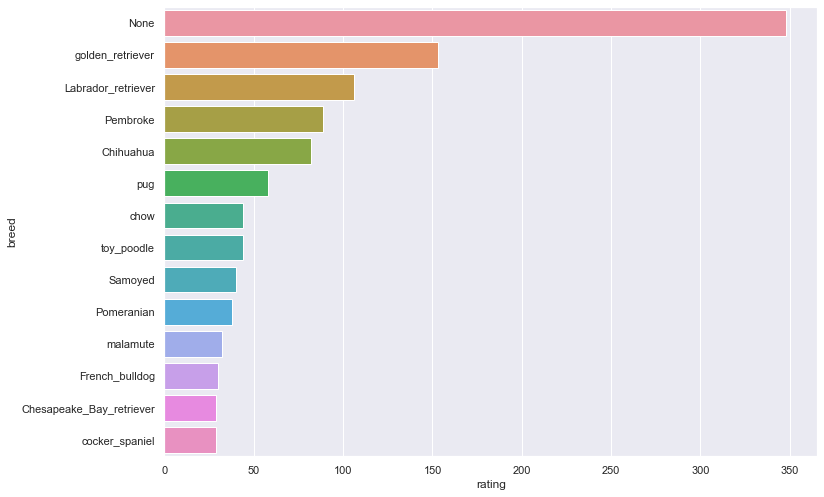

In [51]:
df = clean_twitter_archive.groupby("dog_breed").filter(lambda x: len(x) >= 25)
temp_df =df["dog_breed"].value_counts().to_frame()
df_dict = {"breed":[],"rating":[]}

for j,k in temp_df.iterrows():
    df_dict["breed"].append(j)
    df_dict["rating"].append(k["dog_breed"])

df = pd.DataFrame(df_dict)

sns.barplot(x="rating",y="breed",data=df)

save("popular_dog_breeds")

#### **🏆[2] The Most Popular Dog Names**

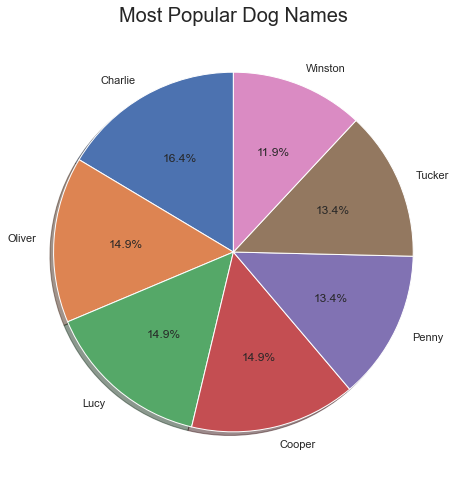

In [52]:
temp_df: pd.DataFrame = clean_twitter_archive\
    .name.value_counts()[0:7].to_frame()
df_dict = {"name": [], "count": []}

for j, k in temp_df.iterrows():
    df_dict["name"].append(j)
    df_dict["count"].append(k["name"])

plt.title("Most Popular Dog Names", fontsize=20)
plt.pie(
    df_dict["count"],
    labels=df_dict["name"],
    autopct='%1.1f%%',
    shadow=True,
    startangle=90
)


save("popular_dog_names")


In [53]:
pd.DataFrame(df_dict)

,name,count
0,Charlie,11
1,Oliver,10
2,Lucy,10
3,Cooper,10
4,Penny,9
5,Tucker,9
6,Winston,8


🎈 There is no doubt that the most popular dog name is "Charlie".

#### **🏆[3] Tweets Over Time**

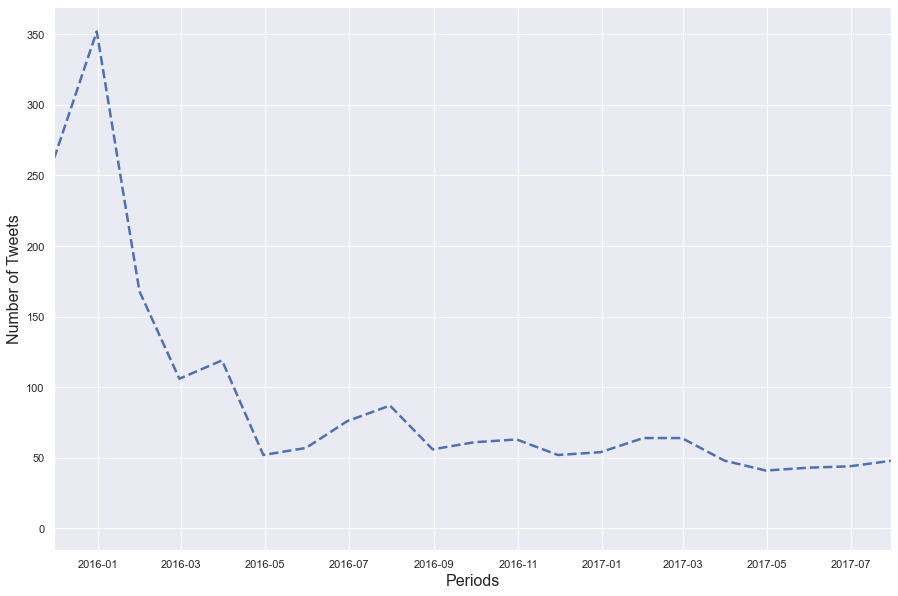

In [54]:
tweets = clean_twitter_archive.groupby(pd.Grouper(
    key='timestamp', freq="M")).count().reset_index()
tweets = tweets[['timestamp', 'tweet_id']]

plt.figure(figsize=(15, 10))
plt.xlim([datetime.date(2015, 11, 30), datetime.date(2017, 7, 30)]);

plt.xlabel('Periods',fontsize=16)
plt.ylabel('Number of Tweets',fontsize=16)
plt.grid(True)

sns.lineplot(
    x=tweets.timestamp, 
    y=tweets.tweet_id,
    palette="tab10", 
    linewidth=2.5,
    linestyle="--"
)

save("tweets_over_time")


#### **🏆[4] Top 20 tweeted breeds**

C:\Users\User\AppData\Local\Programs\Python\Python38-32\lib\site-packages\pandas\core\generic.py:5516: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[name] = value


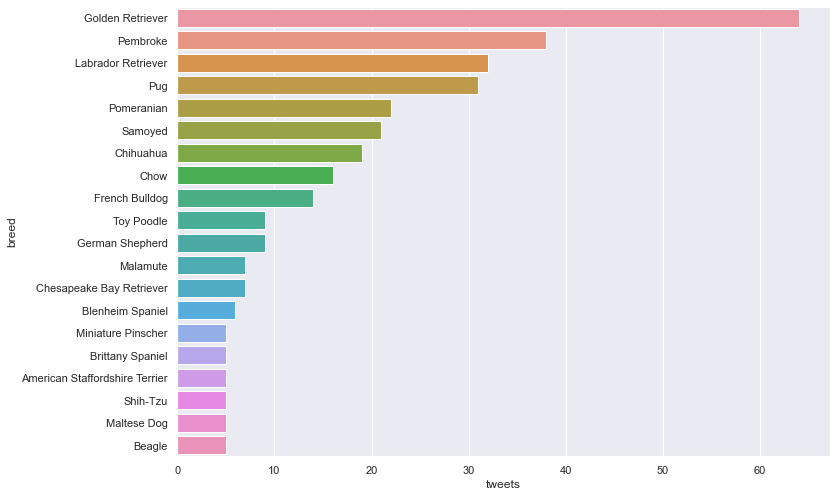

In [55]:
master_df = pd.read_csv('resources/twitter_archive_master.csv')

df = master_df.loc[(master_df.p1_dog == True) & (master_df.p1_conf > 0.8)]
df.p1 = df.p1.str.replace('_', ' ').str.title()
index = df.p1.value_counts().index

df = df.p1.value_counts()[:20].to_frame()
df_dict = {"breed": [], "tweets": []}

for j, k in df.iterrows():
    df_dict["breed"].append(j)
    df_dict["tweets"].append(k["p1"])

sns.barplot(x="tweets", y="breed", data=pd.DataFrame(df_dict))

save("top_20_tweets")

#### **🏆[5] Favorites VS Retweets**

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source_x,text,expanded_urls,rating_numerator,rating_denominator,name,...,p2_conf,p2_dog,p3,p3_conf,p3_dog,time,date,rating,dog_type,dog_breed
0,892420643555336193,NaN,NaN,2017-08-01 16:23:56+00:00,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,https://twitter.com/dog_rates/status/892420643...,13.0,10.0,Phineas,...,0.085851,False,banana,0.07611,False,2017-08-01,2021-12-11 16:23:56,1.3,NaN,None


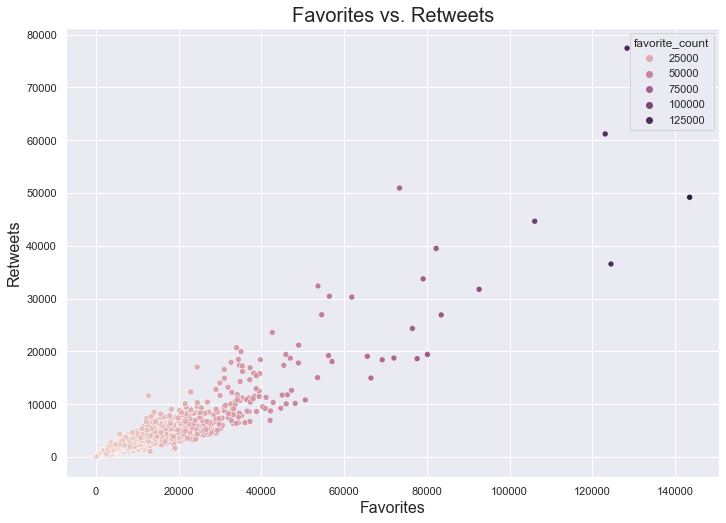

In [56]:
plt.title("Favorites vs. Retweets", fontsize=20)
plt.xlabel("Favorites", fontsize=16)
plt.ylabel("Retweets", fontsize=16)

sns.scatterplot(
    x='favorite_count',
    y='retweet_count',
    data=master_df,
    hue="favorite_count"
)

save("favorites_retweets")


master_df.head(1)

**💗 Abduaziz**